#  MNIST Digit Recognizer — Notebook 1: EDA & Preprocessing

**Dataset:** MNIST (Modified National Institute of Standards and Technology)  
**Task:** Multi-class digit classification (0–9)  
**Framework:** PyTorch  

---
MNIST is loaded directly via `torchvision.datasets` — no manual download needed.
```
outputs/
├── train.pt       ← saved train tensors
├── test.pt        ← saved test tensors
└── dataset_meta.json
```

##  Cell 1 — Imports

In [1]:
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Libraries loaded')
print(f' PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

Libraries loaded
 PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 4050 Laptop GPU


##  Cell 2 — Download & Load MNIST

In [2]:

raw_transform = transforms.ToTensor() 

train_raw = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=raw_transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=raw_transform)

print(f' Dataset downloaded')
print(f'   Train samples : {len(train_raw):,}')
print(f'   Test samples  : {len(test_raw):,}')
print(f'   Image shape   : {train_raw[0][0].shape}  (C, H, W)')
print(f'   Num classes   : {len(train_raw.classes)}')
print(f'   Class labels  : {train_raw.classes}')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [01:01<00:00, 162kB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 110kB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 559kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 6.05MB/s]

 Dataset downloaded
   Train samples : 60,000
   Test samples  : 10,000
   Image shape   : torch.Size([1, 28, 28])  (C, H, W)
   Num classes   : 10
   Class labels  : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']



#  SECTION 1 — Exploratory Data Analysis

##  Cell 3 — Class Distribution

Train class distribution:
  Digit 0 :  5923  (9.9%)  █████████████████████████████
  Digit 1 :  6742  (11.2%)  █████████████████████████████████
  Digit 2 :  5958  (9.9%)  █████████████████████████████
  Digit 3 :  6131  (10.2%)  ██████████████████████████████
  Digit 4 :  5842  (9.7%)  █████████████████████████████
  Digit 5 :  5421  (9.0%)  ███████████████████████████
  Digit 6 :  5918  (9.9%)  █████████████████████████████
  Digit 7 :  6265  (10.4%)  ███████████████████████████████
  Digit 8 :  5851  (9.8%)  █████████████████████████████
  Digit 9 :  5949  (9.9%)  █████████████████████████████


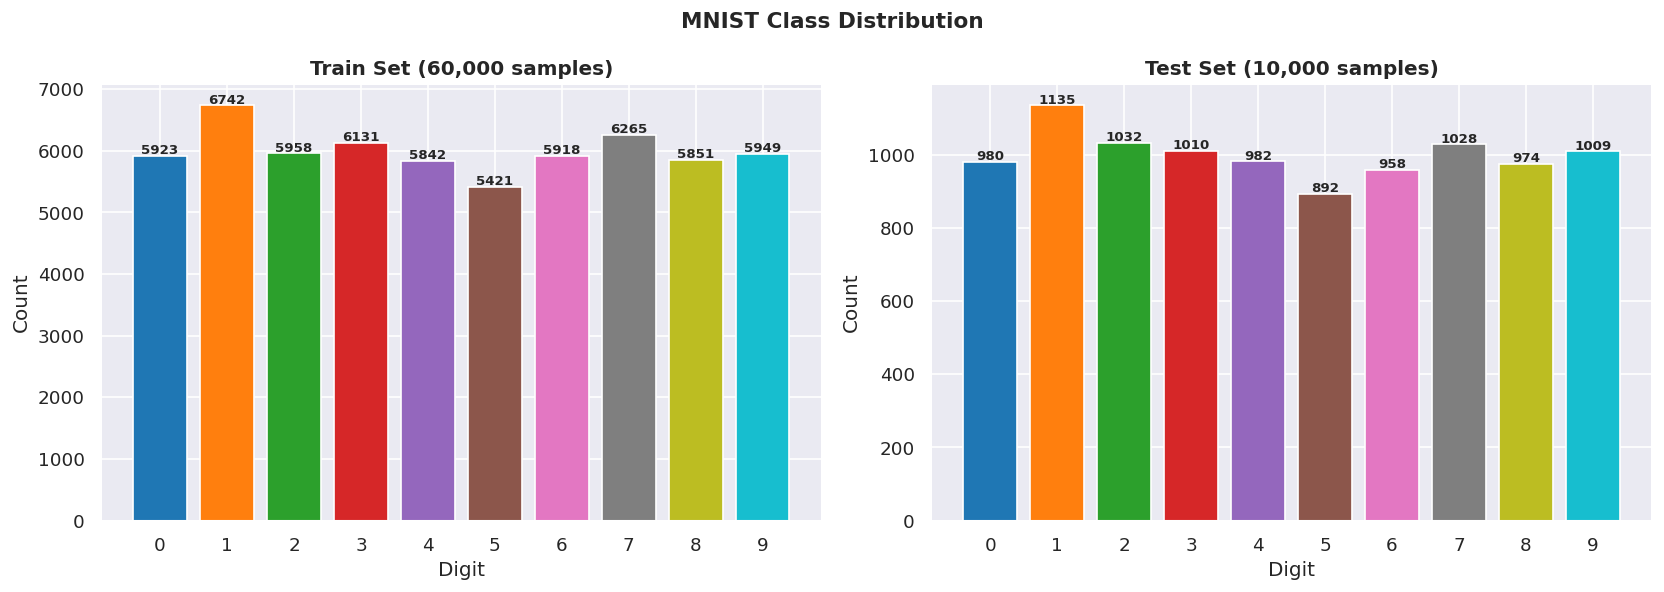


 Dataset is well balanced — all classes approx equal in size


In [3]:
train_labels = train_raw.targets.numpy()
test_labels  = test_raw.targets.numpy()

train_counts = Counter(train_labels)
test_counts  = Counter(test_labels)

print('Train class distribution:')
for digit in range(10):
    bar = '█' * (train_counts[digit] // 200)
    print(f'  Digit {digit} : {train_counts[digit]:>5}  ({train_counts[digit]/len(train_labels)*100:.1f}%)  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MNIST Class Distribution', fontsize=13, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Train
axes[0].bar([str(i) for i in range(10)],
            [train_counts[i] for i in range(10)],
            color=colors, edgecolor='white')
axes[0].set_title(f'Train Set ({len(train_labels):,} samples)', fontweight='bold')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
for i, v in enumerate([train_counts[i] for i in range(10)]):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=8, fontweight='bold')

# Test
axes[1].bar([str(i) for i in range(10)],
            [test_counts[i] for i in range(10)],
            color=colors, edgecolor='white')
axes[1].set_title(f'Test Set ({len(test_labels):,} samples)', fontweight='bold')
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Count')
for i, v in enumerate([test_counts[i] for i in range(10)]):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'\n Dataset is well balanced — all classes approx equal in size')

##  Cell 4 — Sample Images per Digit

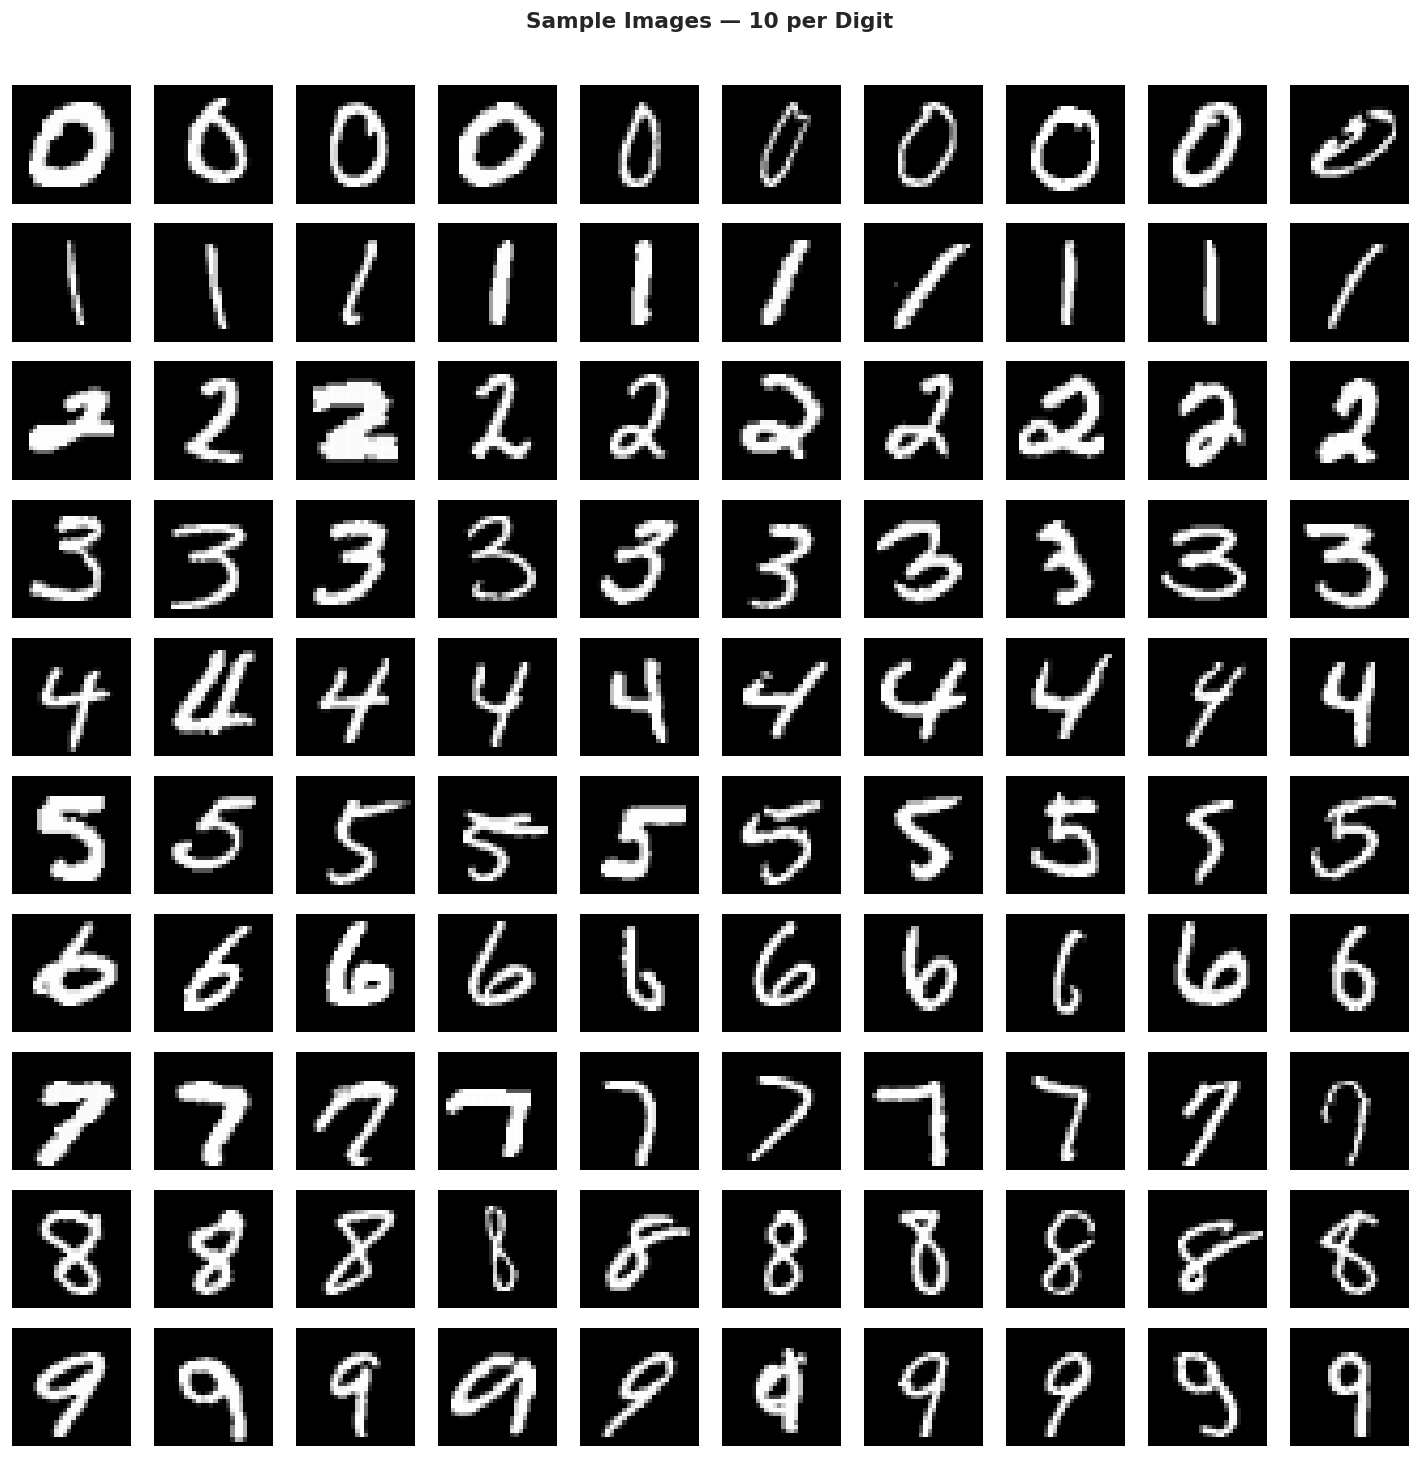

In [4]:
N_SAMPLES = 10

fig, axes = plt.subplots(10, N_SAMPLES, figsize=(N_SAMPLES * 1.2, 10 * 1.2))
fig.suptitle('Sample Images — 10 per Digit', fontsize=13, fontweight='bold', y=1.01)

for digit in range(10):
    # Get indices for this digit
    digit_idx = np.where(train_labels == digit)[0]
    sample_idx = np.random.choice(digit_idx, N_SAMPLES, replace=False)

    for col, idx in enumerate(sample_idx):
        img, label = train_raw[idx]
        axes[digit, col].imshow(img.squeeze(), cmap='gray')
        axes[digit, col].axis('off')
        if col == 0:
            axes[digit, col].set_ylabel(f'Digit {digit}', fontsize=9,
                                        fontweight='bold', rotation=0,
                                        ha='right', va='center', labelpad=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_sample_images.png', bbox_inches='tight')
plt.show()

##  Cell 5 — Pixel Intensity Distribution

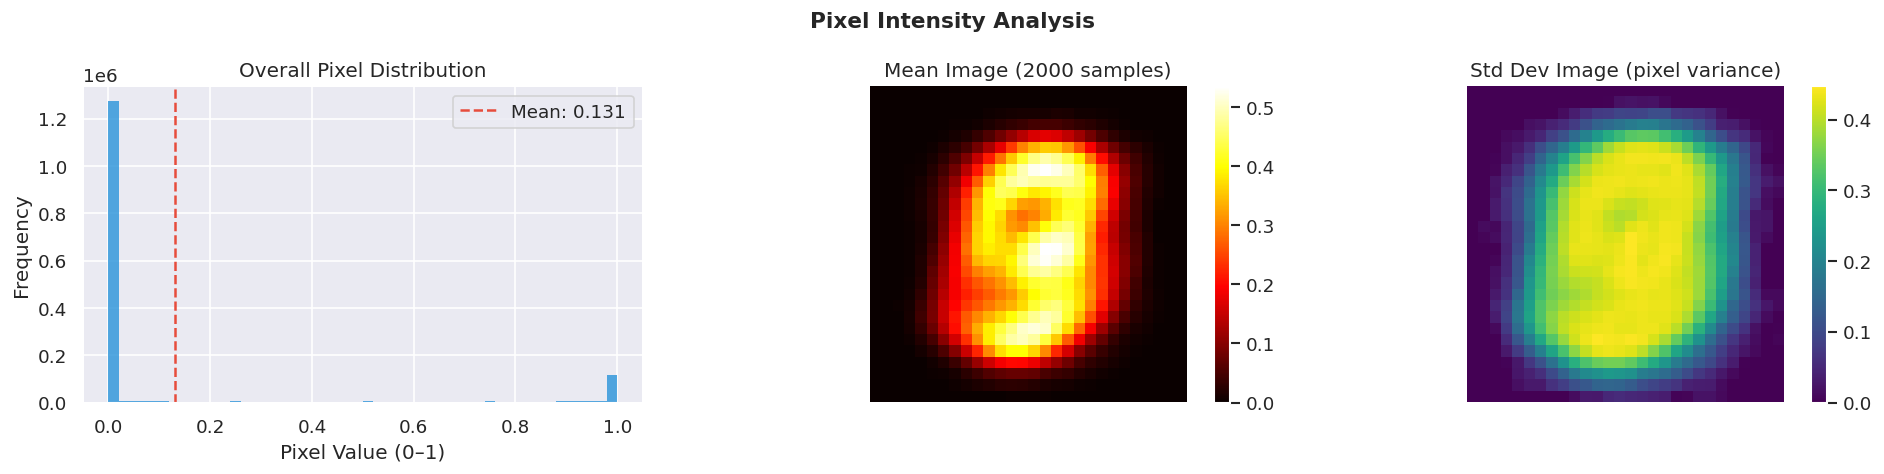

Pixel stats — mean: 0.1306  std: 0.3078
Min: 0.0000  Max: 1.0000


In [5]:
# sample of images to numpy for analysis
sample_loader = DataLoader(train_raw, batch_size=2000, shuffle=True)
sample_imgs, sample_lbls = next(iter(sample_loader))
sample_imgs_np = sample_imgs.numpy().squeeze()   

all_pixels = sample_imgs_np.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Pixel Intensity Analysis', fontsize=13, fontweight='bold')

# Overall histogram
axes[0].hist(all_pixels, bins=50, color='#3498db', edgecolor='none', alpha=0.85)
axes[0].set_title('Overall Pixel Distribution')
axes[0].set_xlabel('Pixel Value (0–1)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(all_pixels.mean(), color='#e74c3c', linestyle='--',
                label=f'Mean: {all_pixels.mean():.3f}')
axes[0].legend()

# Mean image (average of all samples)
mean_img = sample_imgs_np.mean(axis=0)
im = axes[1].imshow(mean_img, cmap='hot')
axes[1].set_title('Mean Image (2000 samples)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# Std image
std_img = sample_imgs_np.std(axis=0)
im2 = axes[2].imshow(std_img, cmap='viridis')
axes[2].set_title('Std Dev Image (pixel variance)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_pixel_distribution.png', bbox_inches='tight')
plt.show()

print(f'Pixel stats — mean: {all_pixels.mean():.4f}  std: {all_pixels.std():.4f}')
print(f'Min: {all_pixels.min():.4f}  Max: {all_pixels.max():.4f}')

## Cell 6 — Average Digit Images (per class)

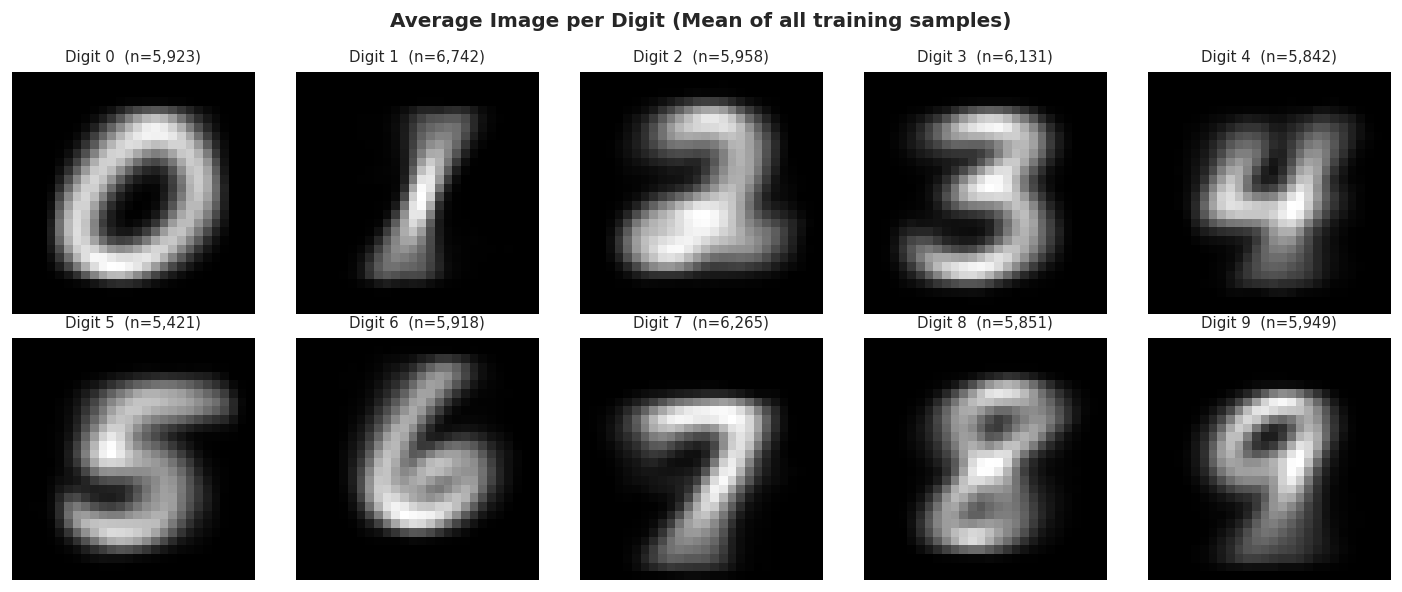

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Average Image per Digit (Mean of all training samples)', fontsize=12, fontweight='bold')

for digit in range(10):
    digit_idx  = np.where(train_labels == digit)[0]
    digit_imgs = np.stack([train_raw[i][0].numpy().squeeze() for i in digit_idx[:500]])
    avg_img    = digit_imgs.mean(axis=0)

    ax = axes[digit // 5, digit % 5]
    ax.imshow(avg_img, cmap='gray')
    ax.set_title(f'Digit {digit}  (n={len(digit_idx):,})', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_average_digits.png', bbox_inches='tight')
plt.show()

##  Cell 7 — Image Properties

In [7]:
img_sample, _ = train_raw[0]

print('─' * 45)
print('  MNIST Image Properties')
print('─' * 45)
print(f'  Shape          : {img_sample.shape}   (C, H, W)')
print(f'  Height × Width : 28 × 28 pixels')
print(f'  Channels       : 1 (Grayscale)')
print(f'  Dtype          : {img_sample.dtype}')
print(f'  Value range    : [{img_sample.min():.1f}, {img_sample.max():.1f}]')
print(f'  Total pixels   : {28*28} per image')
print('─' * 45)

─────────────────────────────────────────────
  MNIST Image Properties
─────────────────────────────────────────────
  Shape          : torch.Size([1, 28, 28])   (C, H, W)
  Height × Width : 28 × 28 pixels
  Channels       : 1 (Grayscale)
  Dtype          : torch.float32
  Value range    : [0.0, 1.0]
  Total pixels   : 784 per image
─────────────────────────────────────────────


##  Cell 8 — Handwriting Style Variation

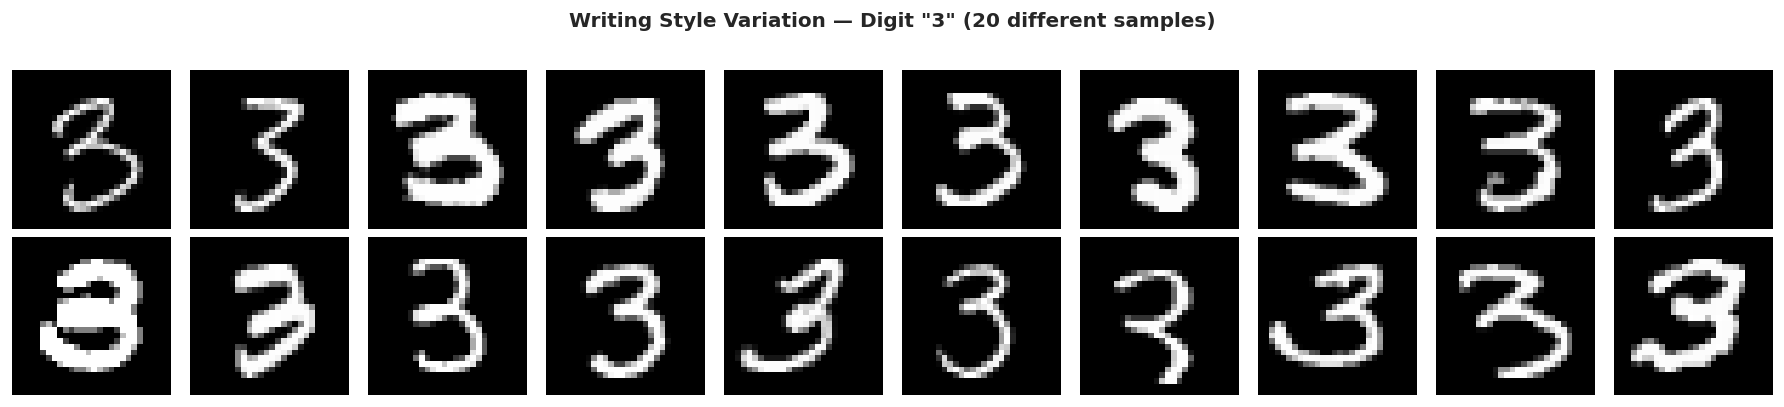

In [8]:
# different writing styles for a single digit
TARGET_DIGIT = 3
digit_idx    = np.where(train_labels == TARGET_DIGIT)[0]
chosen       = np.random.choice(digit_idx, 20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
fig.suptitle(f'Writing Style Variation — Digit "{TARGET_DIGIT}" (20 different samples)',
             fontsize=12, fontweight='bold')

for i, idx in enumerate(chosen):
    img, _ = train_raw[idx]
    ax = axes[i // 10, i % 10]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_style_variation.png', bbox_inches='tight')
plt.show()

---
# SECTION 2 — Preprocessing

##  Cell 9 — Compute Normalization Stats

In [9]:
# mean and std from training set 


loader_for_stats = DataLoader(train_raw, batch_size=1000, shuffle=False, num_workers=2)

mean_sum, std_sum, n_batches = 0.0, 0.0, 0
for imgs, _ in loader_for_stats:
    mean_sum += imgs.mean().item()
    std_sum  += imgs.std().item()
    n_batches += 1

MNIST_MEAN = mean_sum / n_batches
MNIST_STD  = std_sum  / n_batches

print(f'Computed  → mean: {MNIST_MEAN:.4f}  std: {MNIST_STD:.4f}')
print(f'Standard  → mean: 0.1307         std: 0.3081')
print(f'\n Using: mean={MNIST_MEAN:.4f}, std={MNIST_STD:.4f}')

Computed  → mean: 0.1307  std: 0.3080
Standard  → mean: 0.1307         std: 0.3081

 Using: mean=0.1307, std=0.3080


##  Cell 10 — Define Transforms

In [10]:
IMG_SIZE = 28    # MNIST native resolution

# ── Train transforms — with augmentation 
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
    transforms.RandomRotation(degrees=10),            
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  
])

# ── Val / Test transforms — no augmentation 
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

# Reload datasets with transforms
train_full = torchvision.datasets.MNIST(root='./data', train=True,  transform=train_transforms)
test_data  = torchvision.datasets.MNIST(root='./data', train=False, transform=val_transforms)

# Split train → train (90%) + val (10%)
n_train = int(0.9 * len(train_full))
n_val   = len(train_full) - n_train

train_data, val_data = torch.utils.data.random_split(
    train_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print(f' Transforms defined')
print(f'   Train  : {len(train_data):,}  images')
print(f'   Val    : {len(val_data):,}   images')
print(f'   Test   : {len(test_data):,}  images')
print(f'   Normalize → mean={MNIST_MEAN:.4f}  std={MNIST_STD:.4f}')

 Transforms defined
   Train  : 54,000  images
   Val    : 6,000   images
   Test   : 10,000  images
   Normalize → mean=0.1307  std=0.3080


##  Cell 11 — Visualize Augmented Images

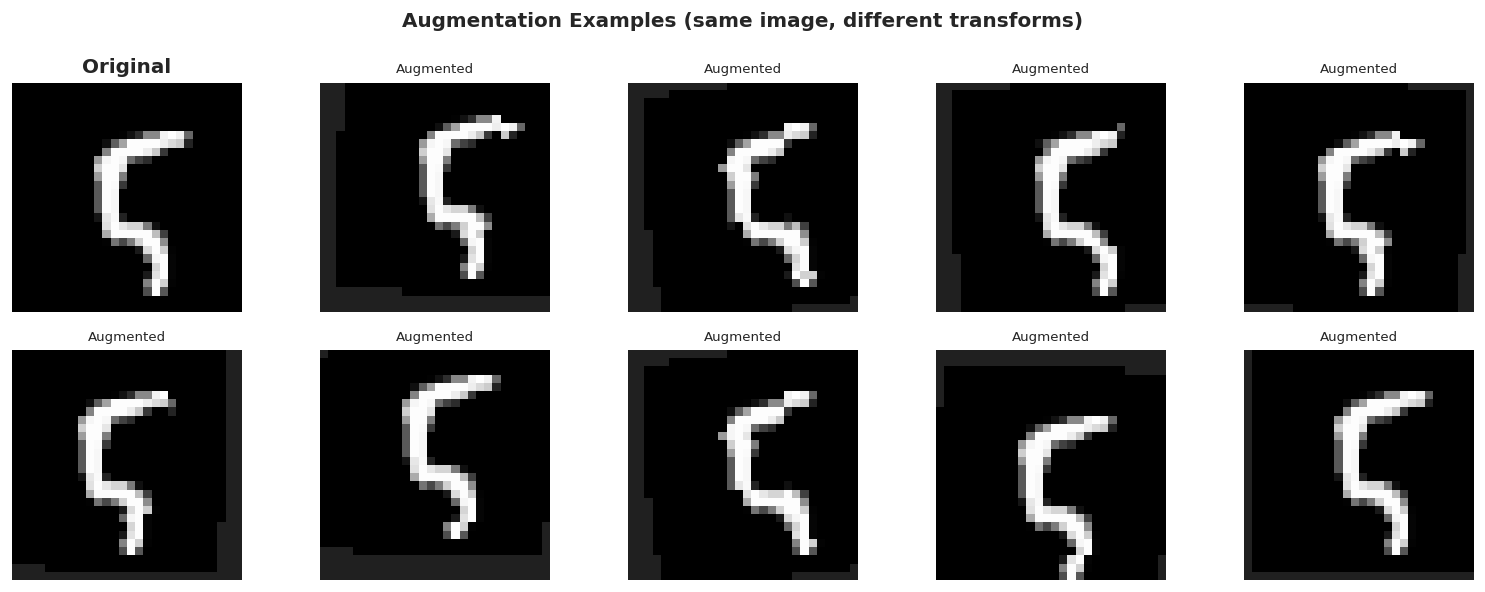

In [11]:
def denormalize(tensor, mean=MNIST_MEAN, std=MNIST_STD):
    return (tensor * std + mean).clamp(0, 1)

# Pick one image and apply augmentation 9 times
raw_img_pil = torchvision.datasets.MNIST(root='./data', train=True)[100][0]  # PIL Image

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
fig.suptitle('Augmentation Examples (same image, different transforms)', fontsize=12, fontweight='bold')

# Original
axes[0, 0].imshow(raw_img_pil, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

flat_axes = [axes[i, j] for i in range(2) for j in range(5)][1:]
for ax in flat_axes:
    aug = train_transforms(raw_img_pil)
    ax.imshow(denormalize(aug).squeeze(), cmap='gray')
    ax.set_title('Augmented', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_augmentation.png', bbox_inches='tight')
plt.show()

##  Cell 12 — Create DataLoaders

In [12]:
BATCH_SIZE  = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Verify a batch
imgs, labels = next(iter(train_loader))
print(f' DataLoaders ready')
print(f'   Batch image shape : {imgs.shape}   (B, C, H, W)')
print(f'   Batch label shape : {labels.shape}')
print(f'   Pixel range       : [{imgs.min():.3f}, {imgs.max():.3f}]')
print(f'   Train batches     : {len(train_loader)}')
print(f'   Val batches       : {len(val_loader)}')
print(f'   Test batches      : {len(test_loader)}')

 DataLoaders ready
   Batch image shape : torch.Size([64, 1, 28, 28])   (B, C, H, W)
   Batch label shape : torch.Size([64])
   Pixel range       : [-0.424, 2.822]
   Train batches     : 844
   Val batches       : 94
   Test batches      : 157


## Cell 13 — Visualize a Batch

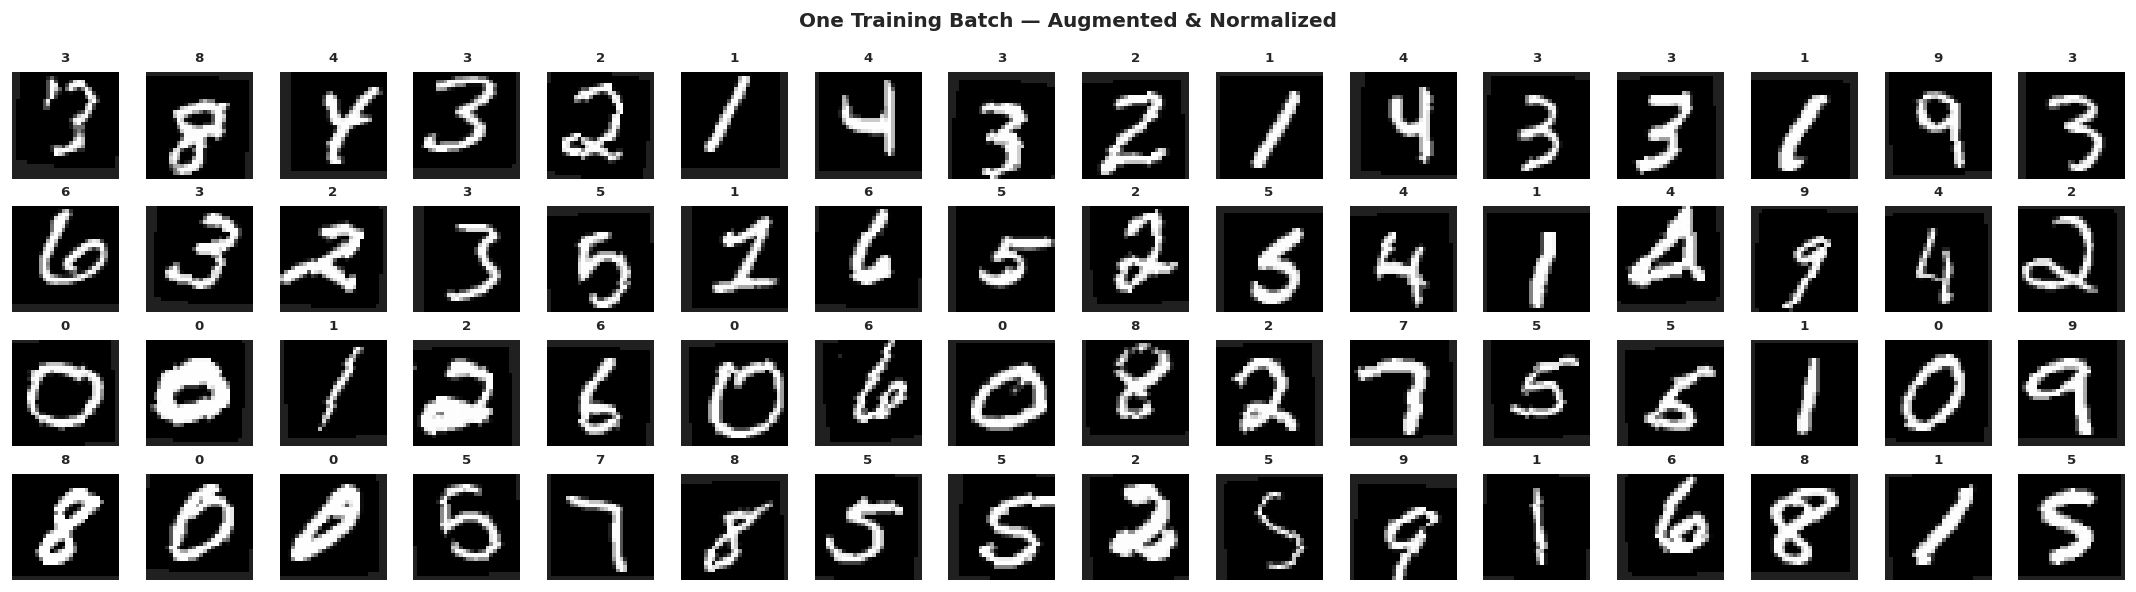

In [13]:
imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 16, figsize=(18, 5))
fig.suptitle('One Training Batch — Augmented & Normalized', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs):
        ax.axis('off')
        continue
    ax.imshow(denormalize(imgs[i]).squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()), fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_batch_sample.png', bbox_inches='tight')
plt.show()

##  Cell 14 — Save Metadata

In [14]:
meta = {
    'num_classes'  : 10,
    'class_names'  : [str(i) for i in range(10)],
    'img_size'     : IMG_SIZE,
    'channels'     : 1,
    'mnist_mean'   : round(MNIST_MEAN, 4),
    'mnist_std'    : round(MNIST_STD, 4),
    'n_train'      : len(train_data),
    'n_val'        : len(val_data),
    'n_test'       : len(test_data),
    'batch_size'   : BATCH_SIZE,
}

with open(OUTPUT_DIR / 'dataset_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved outputs/')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'   {p.name:<45} {p.stat().st_size/1024:.1f} KB')

Saved outputs/
   dataset_meta.json                             0.3 KB
   eda_average_digits.png                        44.0 KB
   eda_class_distribution.png                    57.1 KB
   eda_pixel_distribution.png                    54.8 KB
   eda_sample_images.png                         81.8 KB
   eda_style_variation.png                       32.0 KB
   preprocessing_augmentation.png                25.1 KB
   preprocessing_batch_sample.png                65.7 KB


---
##  Cell 15 — Summary

In [16]:
print('═' * 55)
print('  MNIST  —  EDA & PREPROCESSING COMPLETE')
print('═' * 55)
print(f'  Train / Val / Test : {len(train_data):,} / {len(val_data):,} / {len(test_data):,}')
print(f'  Image size         : 28 × 28 (grayscale)')
print(f'  Classes            : 10 (digits 0–9)')
print(f'  Normalization      : mean={MNIST_MEAN:.4f}  std={MNIST_STD:.4f}')
print(f'  Augmentations      : Rotation(10°), RandomAffine(translate)')
print(f'  Balance            :  Well balanced — ~6,000 per class')
print('═' * 55)


═══════════════════════════════════════════════════════
  MNIST  —  EDA & PREPROCESSING COMPLETE
═══════════════════════════════════════════════════════
  Train / Val / Test : 54,000 / 6,000 / 10,000
  Image size         : 28 × 28 (grayscale)
  Classes            : 10 (digits 0–9)
  Normalization      : mean=0.1307  std=0.3080
  Augmentations      : Rotation(10°), RandomAffine(translate)
  Balance            :  Well balanced — ~6,000 per class
═══════════════════════════════════════════════════════
